In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
h2dtfine = 0.005
h2dtcoarse = 0.01
hehdtfine = 0.004
hehdtcoarse = 0.01

In [3]:
import os

In [4]:
path = './perlgpu/finescale/'
files = os.listdir(path)

In [5]:
h2finedelays = np.arange(1, 33, dtype=np.int16) * 50
h2coarsedelays = np.arange(1, 21, dtype=np.int16) * 40
hehfinedelays = np.arange(1, 26, dtype=np.int16) * 50
hehcoarsedelays = np.arange(1, 21, dtype=np.int16) * 25

In [6]:
h2fine = np.zeros(32)
h2coarse = np.zeros(20)
hehfine = np.zeros(25)
hehcoarse = np.zeros(20)

for f in files:
    if f[-4:]!='.txt':
        continue
    x = f.split('_')
    mol = x[1]
    dt = float(x[3])
    delay = int(x[4])
    y = np.loadtxt(path + f, skiprows=2, delimiter=',')
    if mol=='h2':
        if dt==h2dtfine:
            j = np.where(h2finedelays==delay)[0]
            h2fine[j] = y[1]
        else:
            j = np.where(h2coarsedelays==delay)[0]
            h2coarse[j] = y[1]
    else:
        if dt==hehdtfine:
            j = np.where(hehfinedelays==delay)[0]
            hehfine[j] = y[1]
        else:
            j = np.where(hehcoarsedelays==delay)[0]
            hehcoarse[j] = y[1]

In [7]:
molecules = ['heh+','h2']
bases = ['6-31gss']

# load in 6-31gss set results first
dt = 0.05
delayrange = np.arange(5,555,50)
delayau = dt*delayrange

# 6-31gss set results
lbsr = np.zeros((2, 11))
for i in range(2):
    mol = molecules[i]
    for k in range(11):
        delay = 5 + 50*k
        if mol=='h2':
            freq = '0.063988'
        else:
            freq = '0.127827'
        fname = 'fci_' + mol + '_6-31gss_0.050000_' + str(delay) + '_' + freq + '_0.100000_5.txt'
        x = np.loadtxt('./perlgpu/'+fname, skiprows=2, delimiter=',')
        lbsr[i, k] = x[1]

In [8]:
# load in "fine" results that fill in the region between 5 a.u. and 10 a.u.
fillin1 = np.arange(110,155,5)
fillin2 = np.arange(160,205,5)
fillin = np.concatenate([fillin1, fillin2])
dt = 0.05
fillinau = dt*fillin
lbsrf = np.zeros((2, 18))
for i in range(2):
    mol = molecules[i]
    if mol=='h2':
        freq = '0.063988'
    else:
        freq = '0.127827'
    for k in range(18):
        delay = fillin[k]
        path='./perlgpu/'
        fname = 'fci_' + mol + '_6-31gss_0.050000_' + str(delay) + '_' + freq + '_0.100000_5.txt'
        x = np.loadtxt(path+fname, skiprows=2, delimiter=',')
        lbsrf[i, k] = x[1]

In [9]:
lbau = np.concatenate([delayau[0:3],
                       fillinau[:9],
                       delayau[[3]],
                       fillinau[9:],
                       delayau[4:]])
lbsrall = np.concatenate([lbsr[:,0:3],
                          lbsrf[:,:9],
                          lbsr[:,[3]],
                          lbsrf[:,9:],
                          lbsr[:,4:]], axis=1)

In [10]:
newh2delays = np.arange(10, 580, 10)
newh2errs = np.zeros(newh2delays.shape)
newhehdelays = np.arange(10, 860, 10)
newheherrs = np.zeros(newhehdelays.shape)

mol = 'h2'
for i in range(newh2errs.shape[0]):
    delay = newh2delays[i]
    path='./pinngpu/6-31gss/'
    freq = '0.063988'
    fname = 'fci_' + mol + '_6-31gss_0.025000_' + str(delay) + '_' + freq + '_0.100000_5.txt'
    x = np.loadtxt(path+fname, skiprows=2, delimiter=',')
    newh2errs[i] = x[1]

mol = 'heh+'
for i in range(newheherrs.shape[0]):
    delay = newhehdelays[i]
    path='./pinngpu/6-31gss/'
    freq = '0.127827'
    fname = 'fci_' + mol + '_6-31gss_0.025000_' + str(delay) + '_' + freq + '_0.100000_5.txt'
    x = np.loadtxt(path+fname, skiprows=2, delimiter=',')
    newheherrs[i] = x[1]

newh2au = newh2delays * 0.025
newhehau = newhehdelays * 0.025

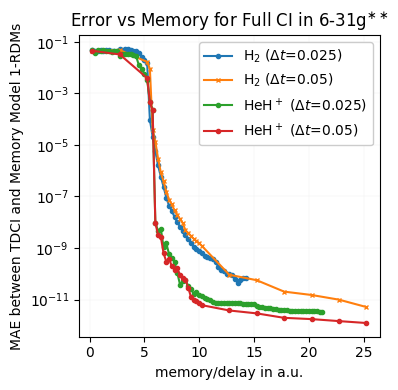

In [11]:
m = 3
plt.figure(figsize=(4,4))
plt.semilogy(newh2au, newh2errs, label=r'H$_2$ ($\Delta t$=0.025)', marker='o', markersize=m)
plt.semilogy(lbau, lbsrall[1,:], label=r'H$_2$ ($\Delta t$=0.05)', marker='x', markersize=m)
plt.semilogy(newhehau, newheherrs, label=r'HeH$^+$ ($\Delta t$=0.025)', marker='o', markersize=m)
plt.semilogy(lbau, lbsrall[0,:], label=r'HeH$^+$ ($\Delta t$=0.05)', marker='o', markersize=m)
plt.xlabel('memory/delay in a.u.')
plt.ylabel('MAE between TDCI and Memory Model 1-RDMs')
plt.title(r'Error vs Memory for Full CI in 6-31g$^{\ast \ast}$')
plt.grid(True, color='lightgrey', linewidth=0.1)
plt.legend(framealpha=1.0, facecolor='white')
plt.tight_layout()
plt.savefig('dtinvarianceFCIFO_6-31gss.pdf')
plt.show()
plt.close()

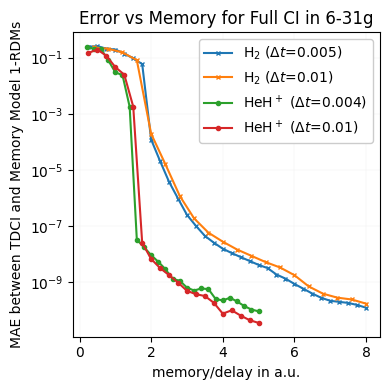

In [12]:
plt.figure(figsize=(4,4))
plt.semilogy(h2dtfine*h2finedelays, h2fine, label=r'H$_2$ ($\Delta t$=0.005)', marker='x', markersize=m)
plt.semilogy(h2dtcoarse*h2coarsedelays, h2coarse, label=r'H$_2$ ($\Delta t$=0.01)', marker='x', markersize=m)
plt.semilogy(hehdtfine*hehfinedelays, hehfine, label=r'HeH$^+$ ($\Delta t$=0.004)', marker='o', markersize=m)
plt.semilogy(hehdtcoarse*hehcoarsedelays, hehcoarse, label=r'HeH$^+$ ($\Delta t$=0.01)', marker='o', markersize=m)
plt.xlabel('memory/delay in a.u.')
plt.ylabel('MAE between TDCI and Memory Model 1-RDMs')
plt.title('Error vs Memory for Full CI in 6-31g')
plt.grid(True, color='lightgrey', linewidth=0.1)
plt.legend(framealpha=1.0, facecolor='white')
plt.tight_layout()
plt.savefig('dtinvarianceFCIFO_6-31g.pdf')
plt.show()
plt.close()
# when propagating 1RDM to T=100.0 a.u.

# Field: amp=0.1, freq=E1-E0 gap, 5 cycles